Federal University of Paraiba \
Center of Tecnology \
Program in Civil and Environmental Engineering

**Subject: Calculate rainfall indices, trend analysis (Mann-Kendall), and remove multiplicity problem (False Discovery Rate) and temporal dependence (Trend Free Pre-Whitening)**


Developed by Jaqueline Coutinho (2025-02-20) \
Last update: 2026-02-11 (CDD)

# Preliminary settings

In [1]:
import os
import ee
import io
import folium
import requests
import geemap
import geemap.colormaps as cm 
import rasterio
import numpy as np
import math
import matplotlib.pyplot as plt
import pymannkendall as mk
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

In [2]:
ee.Authenticate()
ee.Initialize(project='ee-jaquelinevigolo')

In [3]:
roi = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level0") \
  .filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))

In [4]:
# Define the region of interest
asset_path = 'users/jaquelinevigolo/lm_bioma_250'
biomes = ee.FeatureCollection(asset_path)  # Load the asset as a FeatureCollection

# # Filter the feature collection by 'id' field for different regions
amazon = biomes.filter(ee.Filter.eq('CD_Bioma', 1))
caatinga = biomes.filter(ee.Filter.eq('CD_Bioma', 2))
cerrado = biomes.filter(ee.Filter.eq('CD_Bioma', 3))
atlanticForest = biomes.filter(ee.Filter.eq('CD_Bioma', 4))
pampa = biomes.filter(ee.Filter.eq('CD_Bioma', 5))
pantanal = biomes.filter(ee.Filter.eq('CD_Bioma', 6))

# Define time range

In [5]:
# Define the time range
start_date = ee.Date('1987-01-01')
end_date = ee.Date('2024-01-01')

In [6]:
number_of_days = end_date.difference(start_date, 'days')

In [7]:
years = range(start_date.get('year').getInfo(), end_date.get('year').getInfo())

In [8]:
# years

# Load data

## BR-DWGD daily data

In [ ]:
# var = ee.ImageCollection("projects/sat-io/open-datasets/BR-DWGD/PR")

# variable
var_name = 'pr' # ('Rs', 'u2', 'Tmax', 'Tmin', 'RH', 'pr', 'ETo')
var = ee.ImageCollection('projects/ee-alexandrexavier/assets/BR-DWGD') \
    .filterDate(start_date, end_date) \
    .select(var_name)

In [ ]:
# scaling factor
BAND_pr_MULT, BAND_pr_ADD, BAND_pr_UNIT = 0.00686666, 225.0, 'mm'

In [ ]:
# Define a scaling factor
# offset = 225
# scale  = 0.006866665


# # Function to apply the scaling factor to a specific band
# def scaleBand(image):
#     scaledImage = image.select("b1").rename(['pr']).multiply(scale).add(offset) \
#                        .set({'date': image.date().format('yyyy-MM-dd')})
#     return scaledImage.copyProperties(image, image.propertyNames())

# prec = var.map(scaleBand)

In [ ]:
offset = BAND_pr_ADD
scale  = BAND_pr_MULT

# reescalonando
def scaleBand(image):
    scaledImage = image.select(var_name).multiply(scale).add(offset) \
                       .set({'date': image.date().format('yyyy-MM-dd')}) 
    return scaledImage.copyProperties(image, image.propertyNames())

prec = var.map(scaleBand)

## CHIRPS daily data

In [9]:
# Load CHIRPS data and select the total precipitation band
prec = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
  .filterDate(start_date, end_date) \
  .select('precipitation')

## ERA5-Land

In [ ]:
# # Load ERA5-Land data and select the total precipitation band
prec = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR") \
.select('total_precipitation_sum') \
.filterDate(start_date, end_date)

In [ ]:
# prec = prec_in_meters.map(lambda img: img.multiply(1000).copyProperties(img, img.propertyNames()))

## PERSIANN-CDR

In [ ]:
# Load PERSIANN-CDR data and select the total precipitation band
prec = ee.ImageCollection("NOAA/PERSIANN-CDR") \
.select('precipitation') \
.filterDate(start_date, end_date)

## MERRA-2

In [ ]:
# Load MERRA-2 data and select the total precipitation band
prec_hourly = ee.ImageCollection("NASA/GSFC/MERRA/flx/2") \
.select('PRECTOTCORR') \
.filterDate(start_date, end_date)

In [ ]:
# Get information about the projection
precProj = prec_hourly.first().projection()
scale = precProj.nominalScale()
# print(scale.getInfo())

In [ ]:
# Map over the day offsets to create daily images
def make_daily_image(day_offset):
    start = start_date.advance(day_offset, 'day')
    end = start.advance(1, 'day')
    daily_prec = (prec_hourly
                  .filterDate(start, end)
                  .sum()
                  .multiply(3600)  # convert kg/m²/s to mm/day
                  .reproject(crs=precProj, scale=scale)
                  .set('system:time_start', start.millis()))
    return daily_prec

In [ ]:
# Generate the list of days
day_offsets = ee.List.sequence(0, number_of_days.subtract(1))

In [ ]:
# Create the ImageCollection
prec = ee.ImageCollection(day_offsets.map(make_daily_image))

## Visualize map using geeMap

In [ ]:
# Define a map centered
map_rainfall = geemap.Map(center=[-14.24, -53.18], zoom=4)

precipitation_vis = {'min': 0,'max': 40, 'palette': cm.palettes.jet}

# precipitation_vis = {
#     'min': 0,
#     'max': 100,
#     'palette': ['001137', '0aab1e', 'e7eb05', 'ff4a2d', 'e90000'],
# }

# Add the image layer to the map and display it.
map_rainfall.add_layer(prec.first().clip(roi), precipitation_vis, 'Rainfall dataset')
display(map_rainfall)

# Check projection and scale

In [10]:
# Get information about the projection
precProj = prec.first().projection()
scale = precProj.nominalScale()
precGeo = prec.first().geometry()
print(scale.getInfo())

5565.974539663679


# Rainfall indices

## **PRCPTOT**

In [ ]:
# Function to select daily precipitation depth greater than 1mm/day
def rain_depth(prec):
    filtered_dataset = prec.gte(1.0).rename('rainDepth')  # Select rain depth >= 1mm/day and store in a new band
    filtered_prec = prec.updateMask(filtered_dataset)
    return filtered_prec

In [ ]:
# # For ERA5-Land data
# # Function to select daily precipitation depth greater than 1mm/day
# def rain_depth(prec):
#     filtered_dataset = prec.gte(1e-3).rename('rainDepth')  # Select rain depth >= 1mm/day and store in a new band
#     filtered_prec = prec.updateMask(filtered_dataset)
#     return filtered_prec

In [ ]:
# Apply function to the dataset
min_rain_depth = prec.map(rain_depth)
# print(min_rain_depth.first().projection().nominalScale().getInfo())

In [ ]:
# Function to calculate total annual precipitation
def calc_annual_prec(year):
    bd = ee.Date.fromYMD(year, 1, 1)
    ed = bd.advance(1, 'year')
    daily_prec = min_rain_depth.filterDate(bd, ed)
    annual_prec = daily_prec.sum().rename('precipitation').reproject(precProj.crs(), scale=scale)
    return annual_prec.set('year', year)

In [ ]:
# # For ERA5-Land data
# # Function to calculate total annual precipitation
# def calc_annual_prec(year):
#     bd = ee.Date.fromYMD(year, 1, 1)
#     ed = bd.advance(1, 'year')
#     daily_prec = min_rain_depth.filterDate(bd, ed)
#     annual_prec = daily_prec.sum().multiply(1e3).rename('precipitation').reproject(precProj.crs(), scale=scale)
#     return annual_prec.set('year', year)

In [ ]:
# Map the function over the years
annual_prec = ee.ImageCollection([calc_annual_prec(year) for year in years])
# print(annual_prec.first().projection().nominalScale().getInfo())

## Rx1day and R5xday

In [ ]:
def calc_rx1day(year):
    year = ee.Number(year)
    rx1 = (prec
           .filter(ee.Filter.calendarRange(year, year, 'year'))
           .reduce(ee.Reducer.max())
       #     .multiply(1e3) # ERA5-Land
           .rename('precipitation')
           .set('year', year)
           .reproject(precProj.crs(), scale=scale))
    return rx1

In [ ]:
Rx1day = ee.ImageCollection([calc_rx1day(year) for year in years])

In [ ]:
def calc_rx5day(year):
    year = ee.Number(year)

    # Filter and sort daily precipitation
    annual = (prec
              .filter(ee.Filter.calendarRange(year, year, 'year'))
              .sort('system:time_start'))

    img_list = annual.toList(annual.size())
    n_imgs = img_list.size()

    # Rolling window indices (0 → N-5)
    indices = ee.List.sequence(0, n_imgs.subtract(5))

    def rolling_sum(i):
        i = ee.Number(i)

        window = ee.ImageCollection(
            img_list.slice(i, i.add(5))
        ).sum()

        return window

    rolling_5day = ee.ImageCollection.fromImages(
        indices.map(rolling_sum)
    )

    rx5day = (rolling_5day
              .reduce(ee.Reducer.max())
              .rename('precipitation')
              .set('year', year)
              .reproject(precProj.crs(), scale=scale))

    return rx5day

In [ ]:
Rx5day = ee.ImageCollection([calc_rx5day(year) for year in years])

In [ ]:
# Get information about the projection
Rx5day.first().projection().nominalScale().getInfo()

## R10, R20 and R50

In [ ]:
# -------------------------------
# Step 1: Compute daily R20mm mask
# -------------------------------
def calc_R50(image):
    # prec_mm = image.multiply(1e3)  # Convert to mm (ERA5-Land)
    # R50mm_mask = prec_mm.gte(50).rename('R50') # (ERA5-Land)
    R50mm_mask = image.gte(50).rename('R50')
    filtered = image.updateMask(R50mm_mask)
    count = filtered.reduce(ee.Reducer.count()).reproject(precProj.crs(), scale=scale)
    return count.set('system:time_start', image.get('system:time_start'))

In [ ]:
R50mm = prec.map(calc_R50)

In [ ]:
# ---------------------------------------
# Step 2: Calculate annual R20mm per year
# ---------------------------------------

def calc_annual_R50(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')
    daily_R50 = R50mm.filterDate(start, end)
    annual_R50 = daily_R50.sum().rename('R50mm_days').reproject(precProj.crs(), scale=scale)
    return annual_R50.set('year', year)

In [ ]:
annual_R50_collection = ee.ImageCollection([calc_annual_R50(year) for year in years])

In [ ]:
# -------------------------------
# Step 1: Compute daily R20mm mask
# -------------------------------
def calc_R20(image):
    # prec_mm = image.multiply(1e3)  # Convert to mm (ERA5-Land)
    # R20mm_mask = prec_mm.gte(20).rename('R20') # (ERA5-Land)
    R20mm_mask = image.gte(20).rename('R20')
    filtered = image.updateMask(R20mm_mask)
    count = filtered.reduce(ee.Reducer.count()).reproject(precProj.crs(), scale=scale)
    return count.set('system:time_start', image.get('system:time_start'))

In [ ]:
R20mm = prec.map(calc_R20)

In [ ]:
# ---------------------------------------
# Step 2: Calculate annual R20mm per year
# ---------------------------------------

def calc_annual_R20(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')
    daily_R20 = R20mm.filterDate(start, end)
    annual_R20 = daily_R20.sum().rename('R20mm_days').reproject(precProj.crs(), scale=scale)
    return annual_R20.set('year', year)

In [ ]:
annual_R20_collection = ee.ImageCollection([calc_annual_R20(year) for year in years])

In [ ]:
# -------------------------------
# Step 1: Compute daily R10mm mask
# -------------------------------
def calc_R10(image):
    # prec_mm = image.multiply(1e3)  # Convert to mm (ERA5-Land)
    # R10mm_mask = prec_mm.gte(10).rename('R10') # (ERA5-Land)
    R10mm_mask = image.gte(10).rename('R10')
    filtered = image.updateMask(R10mm_mask)
    count = filtered.reduce(ee.Reducer.count()).reproject(precProj.crs(), scale=scale)
    return count.set('system:time_start', image.get('system:time_start'))

In [ ]:
R10mm = prec.map(calc_R10)

In [ ]:
# ---------------------------------------
# Step 2: Calculate annual R10mm per year
# ---------------------------------------

def calc_annual_R10(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')
    daily_R10 = R10mm.filterDate(start, end)
    annual_R10 = daily_R10.sum().rename('R10mm_days').reproject(precProj.crs(), scale=scale)
    return annual_R10.set('year', year)

In [ ]:
annual_R10_collection = ee.ImageCollection([calc_annual_R10(year) for year in years])

## R95PTOT and R99PTOT

In [11]:
# ----------------------------------------- Functions ------------------------------------------

# ---------------------- Get 99th and 95th percentiles ----------------------
def get_99_and_95_percentiles(y):
    bd = ee.Date.fromYMD(y, 1, 1)
    ed = bd.advance(1, 'year')
    yearly_prec = prec.filterDate(bd, ed)
    prec_percentiles = yearly_prec.reduce(ee.Reducer.percentile([99])).rename('pr_p99')  # Only using 99th percentile in Python code
    # prec_percentiles = yearly_prec.reduce(ee.Reducer.percentile([95])).rename('pr_p95')  # Only using 99th percentile in Python code
    return prec_percentiles.set('system:time_start', bd.millis()).reproject(precProj)

In [12]:
# Calculate R99PTOT
rainPercentiles = ee.ImageCollection([get_99_and_95_percentiles(y) for y in years])
# rainPercentiles.first().getInfo()

In [13]:
# ------------------ Filter extremely wet rainfall ------------------
def get_very_rainfall(year):
    bd = ee.Date.fromYMD(year, 1, 1)
    ed = bd.advance(1, 'year')
    one_year_rainfall = prec.filterDate(bd, ed)

    percentile_95 = rainPercentiles.select('pr_p95').filterDate(bd, ed).first()

    def filter_to_percentile_95(image):
        im = ee.Image(image)
        mask = im.gt(percentile_95)
        return im.updateMask(mask)

    yearly_rainfall_from_p95 = ee.ImageCollection(one_year_rainfall.map(filter_to_percentile_95))
    # return yearly_rainfall_from_p95.sum().multiply(1e3).rename('precipitation').set('year', year).reproject(precProj) #for ERA5-Land
    return yearly_rainfall_from_p95.sum().rename('precipitation').set('year', year).reproject(precProj)

In [14]:
rainfall_to_p95 = ee.ImageCollection([get_very_rainfall(y) for y in years]).select('precipitation')
# print(rainfall_to_p95.first().projection().nominalScale().getInfo())
# rainfall_to_p95.getInfo()

In [15]:
# ------------------ Filter extremely wet rainfall ------------------
def get_extremely_rainfall(year):
    bd = ee.Date.fromYMD(year, 1, 1)
    ed = bd.advance(1, 'year')
    one_year_rainfall = prec.filterDate(bd, ed)

    percentile_99 = rainPercentiles.select('pr_p99').filterDate(bd, ed).first()

    def filter_to_percentile_99(image):
        im = ee.Image(image)
        mask = im.gt(percentile_99)
        return im.updateMask(mask)

    yearly_rainfall_from_p99 = ee.ImageCollection(one_year_rainfall.map(filter_to_percentile_99))
    return yearly_rainfall_from_p99.sum().multiply(1e3).rename('precipitation').set('year', year).reproject(precProj) #for ERA5-Land
    # return yearly_rainfall_from_p99.sum().rename('precipitation').set('year', year).reproject(precProj)

In [16]:
rainfall_to_p99 = ee.ImageCollection([get_extremely_rainfall(y) for y in years]).select('precipitation')
# print(rainfall_to_p99.first().projection().nominalScale().getInfo())
# rainfall_to_p99.getInfo()

## TDD

In [ ]:
#Define Dry Day Threshold (Rainfall < 1mm)
def classify_dry_days(image):
    dry = image.lt(1).rename('dry')  # Binary mask: 1 (dry), 0 (wet)
    # dry = image.multiply(1e3).lt(1).rename('dry')  # Binary mask: 1 (dry), 0 (wet) ERA5-Land
    return image.addBands(dry)

In [ ]:
dry_days = prec.map(classify_dry_days)

In [ ]:
# Compute TDD for Each Year
def annual_tdd(year):
    start_date = ee.Date.fromYMD(year, 1, 1)
    end_date = start_date.advance(1, 'year')
    yearly_data = dry_days.filterDate(start_date, end_date)

    tdd = yearly_data.select('dry').reduce(ee.Reducer.sum()).rename('precipitation').reproject(precProj)  # Sum of dry days
    return tdd.set('year', year)  # Add year metadata

In [ ]:
# years = ee.List.sequence(1983, 2022)  # Generate a list of years
tdd_collection = ee.ImageCollection([annual_tdd(year) for year in years])  # Compute TDD for each year
# print(cdd_collection.first().projection().nominalScale().getInfo())

## CDD and CWD
Source: https://www.youtube.com/watch?v=PcayDDiyXWY&t=1s

In [ ]:
# Dry day threshold (mm)
DRY_THRESHOLD = 1.0

In [ ]:
#Define Dry Day Threshold (Rainfall < 1mm)
def classify_dry_days(image):
    dry = image.lt(DRY_THRESHOLD).rename('dry')  # Binary mask: 1 (dry), 0 (wet)
    return image.addBands(dry)

In [ ]:
dry_days = prec.map(classify_dry_days)

In [ ]:
def max_cdd_for_year(year):
    year = ee.Number(year)

    # Filter daily data for the year
    bd = ee.Date.fromYMD(year, 1, 1)
    ed = bd.advance(1, 'year')
    data = dry_days.filterDate(bd, ed)

    # Initial image (zeros)
    init = ee.Image.constant(0) \
        .rename('precipitation') \
        .cast({'precipitation':'long'})
    
        # Iteration function
    def calc_dry_days(current, previous):
        previous = ee.List(previous)
        last_image = ee.Image(previous.get(-1))

        mask = current.remap([0],[1],0)
        updated = last_image.add(mask).multiply(mask)

        return previous.add(updated)

    # Run iteration
    cdd_list = ee.List(
        data.iterate(calc_dry_days, ee.List([init]))
    )

    # Convert to ImageCollection
    cdd_ic = ee.ImageCollection(cdd_list)

    # Annual maximum CDD
    max_cdd = cdd_ic.max() \
        .set('year', year)

    return max_cdd


In [ ]:
annual_cdd_ic = ee.ImageCollection([max_cdd_for_year(year) for year in years])

In [ ]:
#Define Wet Day Threshold (Rainfall >= 1mm)
def classify_wet_days(image):
    wet = image.gte(DRY_THRESHOLD).rename('wet')  # Binary mask: 1 (wet), 0 (dry)
    return image.addBands(wet)

In [ ]:
wet_days = prec.map(classify_wet_days)

In [ ]:
def max_cwd_for_year(year):
    year = ee.Number(year)

    # Filter daily data for the year
    bd = ee.Date.fromYMD(year, 1, 1)
    ed = bd.advance(1, 'year')
    data = wet_days.filterDate(bd, ed)

    # Initial image (zeros)
    init = ee.Image.constant(0) \
        .rename('precipitation') \
        .cast({'precipitation':'long'})
    
        # Iteration function
    def calc_wet_days(current, previous):
        previous = ee.List(previous)
        mask = current.remap([0],[1],0)
        last_image = ee.Image(previous.get(-1))
        updated = last_image.add(mask).multiply(mask)

        return previous.add(updated)

    # Run iteration
    cwd_list = ee.List(
        data.iterate(calc_wet_days, ee.List([init]))
    )

    # Convert to ImageCollection
    cwd_ic = ee.ImageCollection(cwd_list)

    # Annual maximum CDD
    max_cwd = cwd_ic.max() \
        .set('year', year)

    return max_cwd


In [ ]:
annual_cwd_ic = ee.ImageCollection([max_cwd_for_year(year) for year in years])

# Temporal dependence - TFPW

Trend Free Pre-Whitening (TFPW)

In [17]:
dataset = rainfall_to_p99

In [18]:
mean_image = dataset.mean().rename('mean').reproject(crs=precProj, scale=scale)
# Now, export mean_image

In [19]:
after_filter = ee.Filter.lessThan(
    leftField='year',
    rightField='year'
)

joined = ee.ImageCollection(ee.Join.saveAll('after').apply(
    primary=dataset,
    secondary=dataset,
    condition=after_filter
))

In [20]:
def slope(i, j):  # i and j are images
    return ee.Image(j).subtract(i).divide(
        ee.Image(j).getNumber('year').subtract(ee.Image(i).getNumber('year'))
    ).rename('slope').float()

In [21]:
slopes = ee.ImageCollection(joined.map(lambda current:
    ee.ImageCollection.fromImages(current.get('after')).map(lambda image:
        ee.Image(slope(current, image))
    )
).flatten())

In [22]:
sensSlope = slopes.reduce(ee.Reducer.median(), 2).reproject(precProj.crs(), scale=scale)

In [23]:
detrended = dataset.map(lambda image:
    image.subtract(sensSlope.multiply(image.getNumber('year'))).copyProperties(image)
)

In [24]:
mean_detrended = detrended.reduce('mean', 2).reproject(precProj.crs(), scale=scale)

In [25]:
# # 3. Subtrair a média de cada imagem (centralizar a série)
# ---------------------------------------------------------
detrended_lessMean = detrended.map(lambda img:
    img.subtract(mean_detrended).copyProperties(img)
)

In [26]:
# 4. Criar pares consecutivos [Xt-1, Xt] usando listas
# ------------------------------------------------------------
def make_join_collection(collection):
    sorted_list = collection.sort('year').toList(collection.size())
    size = collection.size()
    
    def make_pair(i):
        i = ee.Number(i)
        img1 = ee.Image(sorted_list.get(i))
        img2 = ee.Image(sorted_list.get(i.add(1)))
        return ee.Image.cat([img1, img2]).rename(['Xt_1', 'Xt'])

    # Precisamos criar uma lista de índices até (tamanho - 2)
    indices = ee.List.sequence(0, size.subtract(2))
    return ee.ImageCollection(indices.map(make_pair))

In [27]:
joined_pairs = make_join_collection(detrended_lessMean)

In [28]:
# 5. Calcular o numerador de r1: ∑ (Xt - X̄)(Xt-1 - X̄)
# --------------------------------------------------------
r1_num = joined_pairs.map(lambda img:
    img.select('Xt').multiply(img.select('Xt_1'))
).reduce(ee.Reducer.sum()).reproject(precProj.crs(), scale=scale)

In [29]:
# 6. Calcular o denominador: ∑ (Xt - X̄)^2
# ---------------------------------------------------------------
r1_den = detrended_lessMean.map(lambda img:
    img.multiply(img)
).reduce(ee.Reducer.sum()).reproject(precProj.crs(), scale=scale)

In [30]:
# 7. Calcular o coeficiente r₁ por pixel
# ----------------------------------------
r1_image = r1_num.divide(r1_den).rename('r1')

In [31]:
detrended_pairs = make_join_collection(detrended)

In [32]:
# Pre-Whitening
y_mod = detrended_pairs.map(lambda img:
    img.select('Xt_1').subtract(r1_image.multiply(img.select('Xt'))).rename('precipitation').copyProperties(img)
)

In [33]:
# Return trend to data
y_t = y_mod.map(lambda image:
    image.add(sensSlope.multiply(image.getNumber('year'))).copyProperties(image)
)

In [34]:
# Define number of years (you can also use dataset.size())
n_years = len(years)
std_r1 = 1 / (n_years ** 0.5)
threshold = 2 * std_r1  # critical value for 95% confidence

(r_1) <= -2/sqr(n) \
ou
(r_1) > 2/sqr(n)
se true, rejeita o teste => correlação diferente de zero => pode aplicar MK

In [35]:
# === 7. Significance test: is |r1| > threshold?
r1_abs = r1_image.abs()
critical_value = ee.Number(threshold)
r1_significant = r1_abs.gt(critical_value).rename('r1_significant')
# r1_not_significant = r1_significant.Not()
# if significant, apply Pre-Whitening

In [36]:
def mask_with_r1(image, use_significant=True):
    mask = r1_significant if use_significant else r1_significant.Not()
    return image.updateMask(mask).reproject(precProj.crs(), scale=scale)

In [37]:
masked_significant_r1 = y_t.map(lambda img: mask_with_r1(img, use_significant=True))

In [38]:
masked_not_significant_r1 = dataset.map(lambda img: mask_with_r1(img, use_significant=False))

In [39]:
# Get size of collections (they must be equal)
n_images = masked_significant_r1.size()

# Convert both collections to lists
sig_list = masked_significant_r1.toList(n_images)
not_sig_list = masked_not_significant_r1.toList(n_images)

# Zip the two lists together
zipped_list = sig_list.zip(not_sig_list)

# Function to merge each pair of images
def merge_masked_images(img_pair):
    img_pair = ee.List(img_pair)
    img_sig = ee.Image(img_pair.get(0))
    img_not_sig = ee.Image(img_pair.get(1))
    return img_sig.unmask(img_not_sig)

# Map merge function over zipped list and convert back to ImageCollection
merged_collection = ee.ImageCollection(zipped_list.map(merge_masked_images))


# Mann-Kendall trend analysis

In [40]:
after_filter = ee.Filter.lessThan(
    leftField='year',
    rightField='year'
)

In [41]:
# joined_pos_tfpw = ee.ImageCollection(ee.Join.saveAll('after').apply(
#     primary=dataset,
#     secondary=dataset,
#     condition=after_filter
# ))

In [42]:
joined_pos_tfpw = ee.ImageCollection(ee.Join.saveAll('after').apply(
    primary=merged_collection,
    secondary=merged_collection,
    condition=after_filter
))

In [43]:
# Function to calculate the sign of the difference between two images.
def sign(i, j):
  """Calculates the sign of the difference between two images.

  Args:
    i: The first image.
    j: The second image.

  Returns:
    An ee.Image representing the sign of the difference between the two images.
  """
  return ee.Image(j).neq(i) \
      .multiply(ee.Image(j).subtract(i).clamp(-1, 1)).int()


# ... (Your code for annual precipitation calculation) ...

# Assuming 'image_collection' is your ee.ImageCollection of annual precipitation.

# Calculate the Kendall rank correlation coefficient.
kendall = ee.ImageCollection(joined_pos_tfpw.map(lambda current: 
  ee.ImageCollection.fromImages(current.get('after')).map(lambda image: 
    ee.Image(sign(current, image)).unmask(0)
  )
).flatten()).reduce('sum', 2).reproject(precProj.crs(), scale=scale)

In [44]:
# Values that are in a group (ties). Set all else to zero.
groups = dataset.map(lambda i:
    i.multiply(dataset.map(lambda j: i.eq(j)).sum().gt(1))
)

# Compute tie group sizes in a sequence. The first group is discarded.
def group(array):
    length = array.arrayLength(0)
    # Array of indices. These are 1-indexed.
    indices = ee.Image([1]).arrayRepeat(0, length).arrayAccum(0, ee.Reducer.sum()).toArray(1)
    sorted_array = array.arraySort()
    left = sorted_array.arraySlice(0, 1)
    right = sorted_array.arraySlice(0, 0, -1)
    # Indices of the end of runs.
    mask = left.neq(right).arrayCat(ee.Image(ee.Array([[1]])), 0)
    runIndices = indices.arrayMask(mask)
    # Subtract the indices to get run lengths.
    groupSizes = runIndices.arraySlice(0, 1).subtract(runIndices.arraySlice(0, 0, -1))
    return groupSizes

# See equation 2.6 in Sen (1968).
def factors(image):
    return image.expression('b() * (b() - 1) * (b() * 2 + 5)')

groupSizes = group(groups.toArray())
groupFactors = factors(groupSizes)
groupFactorSum = groupFactors.arrayReduce('sum', [0]).arrayGet([0, 0])

count = joined_pos_tfpw.count()

kendallVariance = factors(count).subtract(groupFactorSum).divide(18).float()
# Map.addLayer(kendallVariance, {'min': 1700, 'max': 85000}, 'kendallVariance')

# Compute Z-statistics.
zero = kendall.multiply(kendall.eq(0))
pos = kendall.multiply(kendall.gt(0)).subtract(1)
neg = kendall.multiply(kendall.lt(0)).add(1)

z = zero.add(pos.divide(kendallVariance.sqrt())).add(neg.divide(kendallVariance.sqrt()))
# Map.addLayer(z, {'min': -2, 'max': 2}, 'z')

# https://en.wikipedia.org/wiki/Error_function#Cumulative_distribution_function
def eeCdf(z):
    return ee.Image(0.5).multiply(ee.Image(1).add(ee.Image(z).divide(ee.Image(2).sqrt()).erf()))

def invCdf(p): #inverse of cumulative distribution
    return ee.Image(2).sqrt().multiply(ee.Image(p).multiply(2).subtract(1).erfInv())

# Compute P-values.
# p_values = ee.Image(1).subtract(eeCdf(z.abs())) #only the upper-tail area
p_values = ee.Image(2).multiply(ee.Image(1).subtract(eeCdf(z.abs()))) #two-tail area

In [45]:
# # Image chunk as a NumPy structured array.
# import numpy
# url = p_values.getDownloadUrl({
#     'bands': 'constant',
#     'region': roi.geometry(),
#     'scale': scale,
#     'format': 'NPY'
# })
# response = requests.get(url)
# p_values_array = numpy.load(io.BytesIO(response.content)).astype(float)
# # print(data)
# # print(data.dtype)

# Multiplicity problem - FDR correction
FDR: False Discovery Rate

In [46]:
# Caminho do seu arquivo GeoTIFF exportado do GEE
path_to_tiff = r'D:\VSCode\MapBiomas-Award\tpfw_p_values\tfpw_p_values_CHIRPS_R99pTOT_1987-2023.tif'

# Abrir o raster
with rasterio.open(path_to_tiff) as src:
    p_values_array = src.read(1)  # lê a primeira banda

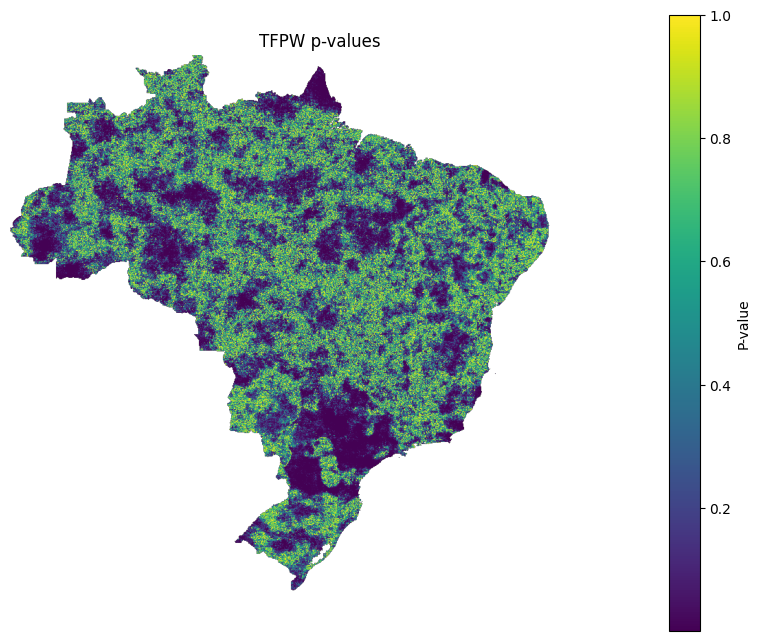

In [47]:
# Exibir imagem
plt.figure(figsize=(10, 8))
plt.imshow(p_values_array.astype(float), cmap='viridis')
plt.colorbar(label='P-value')
plt.title('TFPW p-values')
plt.axis('off')
plt.show()

In [48]:
p_values_array_notNaN = p_values_array[~np.isnan(p_values_array)]
# p_values_array_notNaN

In [49]:
p_values_1d = p_values_array_notNaN.flatten()
# p_values_1d

In [50]:
# FDR correction
reject, pvals_corrected, _, _ = multipletests(p_values_1d, method='fdr_bh')
# pvals_corrected

In [51]:
# pvals_corrected
# print("Original p-value min/max:", p_values_1d.min(), p_values_1d.max())
print("TFPW-adjusted p-value min/max:", p_values_1d.min(), p_values_1d.max())
print("FDR-adjusted min/max:", pvals_corrected.min(), pvals_corrected.max())

TFPW-adjusted p-value min/max: 1.584349007544006e-08 1.0
FDR-adjusted min/max: 0.0021130702754256865 1.0


In [52]:
# Array to image
corrected_image_array = np.full(p_values_array.shape, np.nan)
valid_mask = (~np.isnan(p_values_array)) & (p_values_array >= 0)
corrected_image_array[valid_mask] = pvals_corrected
# image_shape = p_values_array.shape
# corrected_image_array = np.array(pvals_corrected).reshape(image_shape)

# Plot data

## Subplots using plt.imshow (array to image)

In [ ]:
def subplot_images(image_arrays, titles=None, colormap='viridis'):
    """
    Creates a subplot of images using matplotlib.

    Args:
        image_arrays (list): A list of NumPy arrays representing images.
        titles (list, optional): A list of titles for each subplot. Defaults to None.
        colormap (str, optional): The colormap to use for the images. Defaults to 'viridis'.
    """
    num_images = len(image_arrays)

    if num_images == 0:
        print("No images provided.")
        return

    # Calculate subplot grid dimensions
    rows = 1
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(8,6)) # Adjust figure size

    if rows * cols == 1: #handle single image case.
        axes = np.array([axes]) #make axes iterable.

    axes = axes.flatten() #Flatten the array of axes, to use a 1D index.

    for i, image_array in enumerate(image_arrays):
        axes[i].imshow(image_array, cmap=colormap)
        axes[i].axis('off')  # Turn off axis labels and ticks

        if titles and i < len(titles):
            axes[i].set_title(titles[i])

    # Turn off unused axes
    for j in range(num_images, rows * cols):
      axes[j].axis('off')

    plt.tight_layout() #prevents overlapping titles.
    plt.show()

In [ ]:
original_significant_pixels = np.where(p_values_array < 0.05, 1, 0) #adjust the 0.05 threshold as needed.
corrected_significant_pixels = np.where(corrected_image_array < 0.05, 1, 0) #adjust the 0.05 threshold as needed.

images = [original_significant_pixels, corrected_significant_pixels]
titles = ['Original', 'Corrected']

subplot_images(images, titles)

## Trend in percent ##

In [53]:
# # Image chunk as a NumPy structured array.
# import numpy
# url = sensSlope.getDownloadUrl({
#     'bands': 'slope_median',
#     'region': roi.geometry(),
#     'scale': scale,
#     'format': 'NPY'
# })
# response = requests.get(url)
# sensSlope_array = numpy.load(io.BytesIO(response.content)).astype(float)
# # print(data)
# # print(data.dtype)

In [54]:
#Import Sen's slope image
with rasterio.open(r"MapBiomas-Award\sensSlope_rainfal_indices\sensSlope_CHIRPS_R99pTOT_1987-2023.tif") as src:
    sensSlope_array = src.read(1)
    profile = src.profile

In [55]:
# Aplicar máscara: manter apenas valores onde p <= 0.05
masked_sens_slope_array = np.where(corrected_image_array <= 0.05, sensSlope_array, np.nan)


In [56]:
# Aplicar máscara: manter apenas valores onde p > 0.05 (non significant values)
masked_sens_slope_noSign_array = np.where(corrected_image_array > 0.05, sensSlope_array, np.nan)

In [57]:
# mean_image = dataset.mean().rename('mean').reproject(crs=precProj, scale=scale)
# # Now, export mean_image

In [58]:
#Import mean image
with rasterio.open(r"MapBiomas-Award\mean_rainfall_indices\mean_CHIRPS_R99pTOT_1987-2023.tif") as src:
    mean_image_array = src.read(1)
    profile = src.profile

In [59]:
# # Image chunk as a NumPy structured array.
# import numpy
# url = mean_image.getDownloadUrl({
#     'bands': 'mean',
#     'region': roi.geometry(),
#     'scale': scale,
#     'format': 'NPY'
# })
# response = requests.get(url)
# mean_image_array = numpy.load(io.BytesIO(response.content)).astype(float)
# # print(data)
# # print(data.dtype)

In [60]:
# Aplicar máscara: manter apenas valores onde p <= 0.05
masked_mean_image_array = np.where(corrected_image_array <= 0.05, mean_image_array, np.nan)

In [61]:
# Aplicar máscara: manter apenas valores onde p > 0.05 (non significant values)
masked_mean_image_noSign_array = np.where(corrected_image_array > 0.05, mean_image_array, np.nan)

In [62]:
trend_percent = (masked_sens_slope_array / masked_mean_image_array) * 100

In [63]:
trend_percent_noSign = (masked_sens_slope_noSign_array / masked_mean_image_noSign_array) * 100

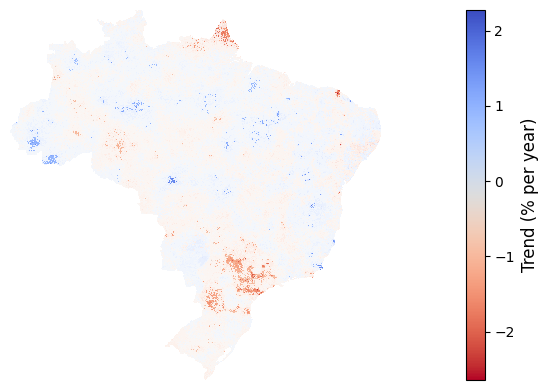

In [64]:
import geopandas as gpd

# Exibir imagem
fig, ax = plt.subplots(figsize=(6, 4))

# Mostrar a imagem (raster de tendência em % por ano)
# im = ax.imshow(mean_image_array, interpolation='none', cmap='viridis', alpha=1)
im = ax.imshow(trend_percent, interpolation='none', cmap='coolwarm_r')
im2 = ax.imshow(trend_percent_noSign, interpolation='none', cmap='coolwarm_r', alpha=.2)

# Adicionar barra de cores
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Trend (% per year)', fontsize=12)

# Título e layout
# ax.set_title('R99PTOT - BR-DWGD', weight='bold', fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.show()


## Histogram

In [ ]:
# Plotar histograma
plt.figure(figsize=(6, 4))
plt.hist(p_values_array.flatten(), bins=50, color='darkgray', alpha = 1, edgecolor='black', label='TFPW p-value')
# plt.hist(original_p_values_array.flatten(), bins=50, color='orange', alpha=0.2, edgecolor='black', label='Original p-value')
plt.hist(corrected_image_array.flatten(), bins=50, color='white', alpha=0.6, edgecolor='red', label='TFPW-FDR p-value')
plt.title('CDD - CHIRPS', weight='bold')
plt.xlabel('p-value', weight='bold')
plt.ylabel('Frequency', weight='bold')
plt.legend()
plt.grid(ls='--')
# plt.savefig('Corrected-p-values-ERA5-Land_TDD', dpi=300)
plt.show()


# Export data

In [ ]:
# ee.data.listOperations()

## to Drive

In [ ]:
import time

# Export p_values as an image to Google Drive
export_task = ee.batch.Export.image.toDrive(
    # image=p_values.clip(roi),
    # image = mean_image.clip(roi),
    image=sensSlope.clip(roi),
    region=roi.geometry(),
    crs=precProj.crs(),
    scale=scale,
    # folder='imgs-trendAnalysis-1987-2023',
    # description='tfpw_p_values_CHIRPS_Rx5day_1987-2023_proj',
    # description='original_p_values_CHIRPS_CDD_1987-2023',
    # description='mean_CHIRPS_Rx5day_1987-2023_proj',
    description='sensSlope_CHIRPS_Rx5day_1987-2023_proj',

    fileFormat='GeoTIFF'
)

export_task.start()

# # Monitor the export task
# def monitor_export(task):
#     while task.active():
#         print(f"Export task is in progress. Status: {task.status()}")
#         time.sleep(60)
#     print(f"Export task finished. Status: {task.status()}")

# monitor_export(export_task)

In [ ]:
# Exportar imagen
def export_image(image, output_folder,
geometry):
 file_name = f"annual_prec_1989.tif"
 output_path = os.path.join(output_folder, file_name)
# Exportar a Google Drive primero
 task = ee.batch.Export.image.toDrive(
 image=annual_prec.first(),
 description="annual_prec_1989",
 region=geometry.bounds().getInfo()['coordinates'],
 crs=precProj.crs(),
 scale=scale,
 fileFormat='GeoTIFF'
 )
 task.start()
 # Descargar desde Google Drive con geemap
 print(f"Tarea de exportación iniciada. Espere mientras se descarga.")
 geemap.download_ee_image(
 annual_prec,
 output_path,
 region=geometry.bounds().getInfo()['coordinates'],
 crs=precProj.crs(),
 scale=scale
 )
 print(f"Raster descargado en: {output_path}")

 # Exportar el raster de deforestation
 export_image(image, output_folder, pantanal)


## to folder in computer

In [ ]:
# Significant values
# Define the output file path
output_path = r'MapBiomas-Award\trend_Percent\trendPercent_CHIRPS_Rx5day_1987-2023_proj.tif'

# Export the trend_percent array as a TIFF image
with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(trend_percent.astype(rasterio.float32), 1)

print(f"Trend percentage image exported to: {output_path}")

In [65]:
# Non Significant values
# Define the output file path
output_path = r'MapBiomas-Award\trend_Percent\trendPercent_noSign_CHIRPS_R99pTOT_1987-2023.tif'

# Export the trend_percent array as a TIFF image
with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(trend_percent_noSign.astype(rasterio.float32), 1)

print(f"Non-significant trend percentage image exported to: {output_path}")

Non-significant trend percentage image exported to: MapBiomas-Award\trend_Percent\trendPercent_noSign_CHIRPS_R99pTOT_1987-2023.tif


## as CSV to Google Drive

In [ ]:
# Define the region of interest
asset_path = 'users/jaquelinevigolo/lm_bioma_250'
biomes = ee.FeatureCollection(asset_path)  # Load the asset as a FeatureCollection

# # Filter the feature collection by 'id' field for different regions
amazon = biomes.filter(ee.Filter.eq('CD_Bioma', 1))
caatinga = biomes.filter(ee.Filter.eq('CD_Bioma', 2))
cerrado = biomes.filter(ee.Filter.eq('CD_Bioma', 3))
atlanticForest = biomes.filter(ee.Filter.eq('CD_Bioma', 4))
pampa = biomes.filter(ee.Filter.eq('CD_Bioma', 5))
pantanal = biomes.filter(ee.Filter.eq('CD_Bioma', 6))

In [ ]:
# List of region IDs
region_ids = [1, 2, 3, 4, 5, 6]

In [ ]:
#Import trend percent image
trend_image = ee.Image(
    "projects/ee-jaquelinevigolo/assets/trendPercent_CHIRPS_R20_1987-2023")

In [ ]:
import ee
import time

ee.Initialize()

# Make sure band is properly named
trend_image = trend_image.rename('trendPercent')

for region_id in region_ids:

    print(f'Processing biome {region_id}')

    # Select biome
    sample_region = biomes.filter(
        ee.Filter.eq('CD_Bioma', region_id)
    ).geometry()

    # Add coordinate bands
    image_with_coords = trend_image.addBands(
        ee.Image.pixelLonLat()
    )

    # Sample pixels
    sampled = image_with_coords.sample(
        region=sample_region,
        scale=scale
    ).select(['longitude', 'latitude', 'trendPercent'])

    # Export to Drive
    task = ee.batch.Export.table.toDrive(
        collection=sampled,
        description=f'Export_{region_id}',
        folder='significantTrendPercent_pixels',
        fileNamePrefix=f'R20_percentTrend_CHIRPS_{region_id}',
        fileFormat='CSV'
    )

    task.start()

    # while task.active():
    #     print(f'Biome {region_id} exporting...')
    #     time.sleep(60)

    # print(f'Biome {region_id} finished.')


In [ ]:
# Define a map centered
map_lulc = geemap.Map(center=[-14.24, -53.18], zoom=4)

trend_viz = {
    "min": -1,
    "max": 1,
    "palette": ["#b2182b", "#ef8a62", "#fddbc7", '#d1e5f0', '#67a9cf', '#2166ac']}

# Add the image layer to the map and display it.

map_lulc.add_layer(trend_image, trend_viz, 'Rainfall trend')
map_lulc.add_layer(mean_image_neg, trend_viz, 'Negative rainfall trend')


display(map_lulc)